In [1]:
import qflux
from qflux.error_mitigation.rbm import RBM

import jax
import jax.numpy as jnp
import numpy as np

ModuleNotFoundError: No module named 'qflux'

## Testing the RBM functions

In [14]:
# Test Flax RBM
key = jax.random.PRNGKey(0)

model = RBM(alpha=2)

x = jnp.array([[0., 1., 0., 1.]])

params = model.init(key, x)

logpsi = model.apply(params, x)

print(logpsi)

[0.00824443-0.00369486j]


/Users/briangitahi/Desktop/QFLUX/qflux/.venv/lib/python3.12/site-packages/jax/_src/nn/initializers.py:171: UserWarning: Explicitly requested dtype complex128 is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return random.normal(key, shape, dtype,
/Users/briangitahi/Desktop/QFLUX/qflux/.venv/lib/python3.12/site-packages/jax/_src/nn/initializers.py:172: UserWarning: Explicitly requested dtype complex128 requested in array is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  out_sharding=out_sharding) * jnp.array(stddev, dtype)


In [15]:
# Bell State demo with qflux

from qflux.error_mitigation.rbm import model_probs

probs = model_probs()

for basis, p in probs.items():
    print(basis)
    print(p)
    print("sum =", p.sum())

ZZ
[1.87469973e-33 5.00000000e-01 5.00000000e-01 1.87469973e-33]
sum = 1.0
XX
[1.87469973e-33 5.00000000e-01 5.00000000e-01 1.87469973e-33]
sum = 1.0
YY
[0.  0.5 0.5 0. ]
sum = 1.0


In [16]:
np.allclose(probs["ZZ"].sum(),1)
np.allclose(probs["XX"].sum(),1)
np.allclose(probs["YY"].sum(),1)

True

In [17]:
# Test complex rbm sampling
from qflux.error_mitigation.rbm import ComplexRBM

rng = np.random.default_rng(123)
rbm = ComplexRBM(n_visible=2, n_hidden=2, rng=rng)
samples = rbm.metropolis_samples(n_samples=20, burn_in=100, thin=5)

print(samples)
print(samples.shape)

[[-1 -1]
 [-1  1]
 [-1 -1]
 [-1  1]
 [-1 -1]
 [ 1 -1]
 [ 1  1]
 [ 1 -1]
 [-1 -1]
 [ 1 -1]
 [ 1  1]
 [-1  1]
 [ 1  1]
 [ 1 -1]
 [-1 -1]
 [-1 -1]
 [-1  1]
 [-1 -1]
 [ 1 -1]
 [-1 -1]]
(20, 2)


In [18]:
# Test the local estimator
from qflux.error_mitigation.rbm import (ComplexRBM, estimate_observable_mc)

rbm = ComplexRBM(2,2)
pauli_terms = [(1.0,"ZZ")]

mean, err = estimate_observable_mc(rbm, pauli_terms, n_samples=500)

print(mean)
print(err)

(-0.008+1.2400803688866961e-19j)
0.04471992844359213


## Testing RIDA, ZNE, and TREX Mitigation techniques

In [19]:
# Test ZNE

from qiskit_aer import AerSimulator
from qflux.error_mitigation.mitigation import (
    random_ansatz,
    true_expectation_z,
    make_noise_model,
    run_counts,
    measure_z_expectation,
    zne_exponential_fit,
)

backend = AerSimulator()

qc = random_ansatz(n_qubits=5, depth=4)

true_val = true_expectation_z(qc)

nm = make_noise_model(scale=1)
counts = run_counts(qc, shots=5000, backend=backend, noise_model=nm)
noisy_val = measure_z_expectation(counts)

print(f"Ideal expectation : {true_val:.4f}")
print(f"Noisy expectation : {noisy_val:.4f}")

zne = zne_exponential_fit(
    noisy_val,
    noisy_val*0.9,
    noisy_val*0.8
)

print(f"Example ZNE extrapolation : {zne:.4f}")

Ideal expectation : -0.2311
Noisy expectation : -0.2132
Example ZNE extrapolation : -0.2239


In [20]:
# Test TREX

from qiskit_aer import AerSimulator
from qflux.error_mitigation.mitigation import (random_ansatz, make_noise_model, trex_estimate)

backend = AerSimulator()
qc = random_ansatz()
noise = make_noise_model()
trex = trex_estimate(qc, shots=8000, backend=backend, noise_model=noise)

print("TREX estimate =", trex)

TREX estimate = 0.09314097696785624


Unmitigated : [0.05519866 0.01475092]
RIDA        : [0.0534968  0.01889789]
ZNE         : [0.10649405 0.02363251]
ZNE+TREX    : [0.67619984 0.12429079]


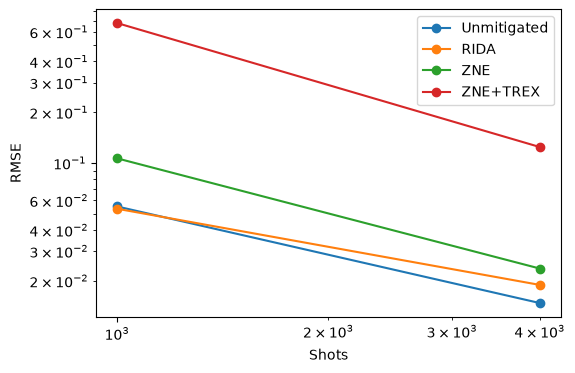

In [21]:
# Test the full comparison

import matplotlib.pyplot as plt

from qflux.error_mitigation.mitigation import experiment

shots = [1000, 4000]

rmse_u, rmse_r, rmse_z, rmse_zt = experiment(
    shots,
    num_trials=3,
    seed=7,
)

print("Unmitigated :", rmse_u)
print("RIDA        :", rmse_r)
print("ZNE         :", rmse_z)
print("ZNE+TREX    :", rmse_zt)

plt.figure(figsize=(6,4))

plt.plot(shots, rmse_u, "o-", label="Unmitigated")
plt.plot(shots, rmse_r, "o-", label="RIDA")
plt.plot(shots, rmse_z, "o-", label="ZNE")
plt.plot(shots, rmse_zt, "o-", label="ZNE+TREX")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Shots")
plt.ylabel("RMSE")
plt.legend()

plt.show()